In [3]:
import os
from pathlib import Path

def encontrar_raiz_repo(marcador=".git"):
    caminho = Path.cwd()
    for pasta in [caminho, *caminho.parents]:
        if (pasta / marcador).exists():
            return pasta
    raise FileNotFoundError(f"Não achei {marcador} subindo a partir de {caminho}")

RAIZ = encontrar_raiz_repo()
print(RAIZ)

/usr/src/myapp


In [9]:
import pandas as pd
import numpy
from sklearn.model_selection import train_test_split

## Importando dados

In [5]:
features = pd.read_csv(RAIZ / "data/processed/features.csv", index_col=0)
metadata_cols = pd.read_csv(RAIZ / "data/processed/metadata_filtrada.csv").set_index("sample")[["Species", "source_type", "WHO_Priority"]]

In [6]:
features.head()

,pct_genes_cromossomal_efflux,mdr_score_cromossomal,mdr_score_plasmidial,pct_contigs_plasmidial,pct_plasmidial_amr,pct_plasmidial_conjugacao_amr,n_proviruses_por_mb,gc_diff_plasmid_cromossomo,virulence_score_cromossomal,virulence_score_plasmidial,cat_plasmidial_beta-lactam
sample,,,,,,,,,,,
GCA_000216055.2,0.000000,1,0,1.655629,0.000000,0.000000,0.896445,0.18,0,0,0
GCA_000316425.1,2.127660,13,6,5.675676,4.761905,0.000000,1.540586,-2.92,8,4,2
GCA_000223095.2,16.666667,7,0,6.349206,0.000000,0.000000,0.774247,-3.05,6,1,0
GCA_036761135.1,10.000000,10,5,18.269231,10.526316,2.631579,0.252947,0.31,4,0,1
GCA_003670255.1,14.285714,8,5,22.406639,9.259259,1.851852,0.999419,0.90,4,0,1


In [8]:
metadata_cols.head()

,Species,source_type,WHO_Priority
sample,,,
GCA_000216055.2,Leptospira interrogans,Other,Other
GCA_000316425.1,Escherichia coli,Unknown,Critical
GCA_000223095.2,Vibrio cholerae,Gastrointestinal,Other
GCA_036761135.1,Acinetobacter bereziniae,Gastrointestinal,Other
GCA_003670255.1,Acinetobacter bereziniae,Respiratory,Other


## Fazendo o split

In [25]:
metadata_cols.loc[features.index]['WHO_Priority'].head()

sample
GCA_000216055.2       Other
GCA_000316425.1    Critical
GCA_000223095.2       Other
GCA_036761135.1       Other
GCA_003670255.1       Other
Name: WHO_Priority, dtype: object

In [ ]:
df_train, df_temp = train_test_split(
    features, 
    test_size=0.3, 
    random_state=42,
    stratify=metadata_cols.loc[features.index, "WHO_Priority"]
)

df_valid, df_test = train_test_split(
    df_temp, 
    test_size=0.66, 
    random_state=42,
    stratify=metadata_cols.loc[df_temp.index, "WHO_Priority"]
)

In [23]:
pct_train = round((df_train.shape[0] / features.shape[0]), 2)
pct_valid = round((df_valid.shape[0] / features.shape[0]), 2)
pct_test = round((df_test.shape[0] / features.shape[0]), 2)

print("-" * 10)
print(f"df_train: {df_train.shape}, - {pct_train}")
print(f"df_valid: {df_valid.shape} - {pct_valid}")
print(f"df_test: {df_test.shape} - {pct_test}")

----------
df_train: (4926, 11), - 0.7
df_valid: (718, 11) - 0.1
df_test: (1394, 11) - 0.2


## Vendo a proporção dos dados

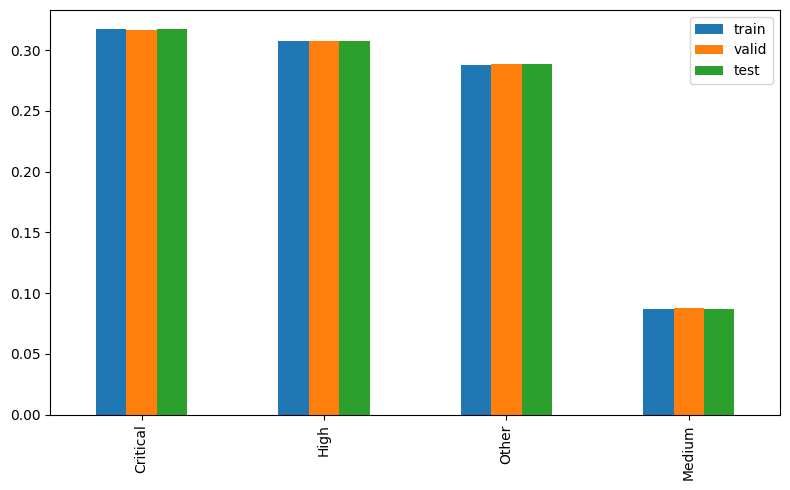

In [28]:
import matplotlib.pyplot as plt

distrib = pd.DataFrame({
    "train": metadata_cols.loc[df_train.index, "WHO_Priority"].value_counts(normalize=True),
    "valid": metadata_cols.loc[df_valid.index, "WHO_Priority"].value_counts(normalize=True),
    "test": metadata_cols.loc[df_test.index, "WHO_Priority"].value_counts(normalize=True),
})

distrib.plot(kind="bar", figsize=(8, 5))
plt.tight_layout()
plt.show()

## Salvando

In [30]:
df_estruturada = RAIZ / "data/processed/df_estruturada"
df_estruturada.mkdir(parents=True, exist_ok=True)

df_train.to_csv(df_estruturada / "df_train.csv")
df_test.to_csv(df_estruturada / "df_test.csv")
df_valid.to_csv(df_estruturada / "df_valid.csv")